In [ ]:
import pandas as pd

df = pd.read_csv("Tweets.csv")
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Drop rows where 'text' is NaN to avoid the ValueError
df = df.dropna(subset=['text'])

vectorizer = TfidfVectorizer(max_features=500)
X = vectorizer.fit_transform(df["text"]).toarray()

print("Shape:", X.shape)

Shape: (27480, 500)


In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test = train_test_split(X, test_size=0.2)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

input_dim = x_train.shape[1]
latent_dim = 2

# Sampling Layer
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Encoder
inputs = layers.Input(shape=(input_dim,))
x = layers.Dense(128, activation="relu")(inputs)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)
z = Sampling()([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z])

# Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(128, activation="relu")(latent_inputs)
outputs = layers.Dense(input_dim, activation="sigmoid")(x)

decoder = Model(latent_inputs, outputs)

# VAE Model
class VAE(Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=-1
                )
            )

            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                    axis=1
                )
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {"loss": total_loss}

vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")

vae.fit(x_train, epochs=10, batch_size=64)

Epoch 1/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.0000e+00
Epoch 2/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0000e+00
Epoch 3/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0000e+00
Epoch 4/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0000e+00
Epoch 5/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0000e+00
Epoch 6/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0000e+00
Epoch 7/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0000e+00
Epoch 8/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0000e+00
Epoch 9/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0000e+00
Epoch 10/10
344/344 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0000e+00


172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


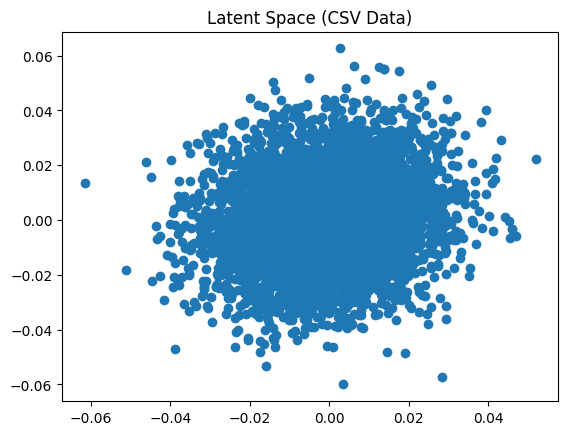

In [ ]:
import matplotlib.pyplot as plt

z_mean, _, _ = encoder.predict(x_test)

plt.scatter(z_mean[:, 0], z_mean[:, 1])
plt.title("Latent Space (CSV Data)")
plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch: 0 Generator Loss: 0.63052845
Epoch: 500 Generator Loss: 9.816507
Epoch: 1000 Generator Loss: 16.614183
Epoch: 1500 Generator Loss: 17.615736
Epoch: 2000 Generator Loss: 16.220049
Epoch: 2500 Generator Loss: 16.175056
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


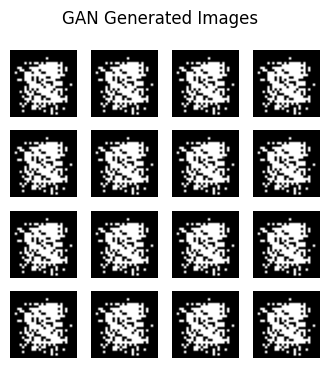

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# MNIST dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_train = x_train.reshape(-1, 784)

noise_dim = 100

# Generator
generator = tf.keras.Sequential([
    layers.Input(shape=(noise_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(784, activation="sigmoid")
])

# Discriminator
discriminator = tf.keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

discriminator.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# GAN model
discriminator.trainable = False

gan_input = layers.Input(shape=(noise_dim,))
fake_img = generator(gan_input)
gan_output = discriminator(fake_img)

gan = tf.keras.Model(gan_input, gan_output)
gan.compile(optimizer="adam", loss="binary_crossentropy")

# Training
epochs = 3000
batch_size = 128

for epoch in range(epochs):
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_images = x_train[idx]

    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    fake_images = generator.predict(noise, verbose=0)

    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    discriminator.trainable = True
    d_loss_real = discriminator.train_on_batch(real_images, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_images, fake_labels)

    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    valid_labels = np.ones((batch_size, 1))

    discriminator.trainable = False
    g_loss = gan.train_on_batch(noise, valid_labels)

    if epoch % 500 == 0:
        print("Epoch:", epoch, "Generator Loss:", g_loss)

# Generate images
noise = np.random.normal(0, 1, (16, noise_dim))
generated_images = generator.predict(noise)

plt.figure(figsize=(4, 4))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("GAN Generated Images")
plt.show()

In [ ]:
!pip install -q torch-geometric torch-scatter torch-sparse

import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

# Cora citation dataset
dataset = Planetoid(root="/tmp/Cora", name="Cora")
data = dataset[0]

print("Dataset:", dataset)
print("Number of nodes:", data.num_nodes)
print("Number of edges:", data.num_edges)
print("Number of features:", dataset.num_features)
print("Number of classes:", dataset.num_classes)

# GCN Model
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index

        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)

        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

model = GCN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Training
for epoch in range(200):
    model.train()
    optimizer.zero_grad()

    out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())

# Testing
model.eval()
out = model(data)
pred = out.argmax(dim=1)

correct = pred[data.test_mask] == data.y[data.test_mask]
accuracy = int(correct.sum()) / int(data.test_mask.sum())

print("Test Accuracy:", accuracy)

  Preparing metadata (setup.py) ... done


Processing...
Done!


Dataset: Cora()
Number of nodes: 2708
Number of edges: 10556
Number of features: 1433
Number of classes: 7
Epoch: 0 Loss: 1.9470657110214233
Epoch: 20 Loss: 0.2699236273765564
Epoch: 40 Loss: 0.06561978906393051
Epoch: 60 Loss: 0.05660170316696167
Epoch: 80 Loss: 0.05051445960998535
Epoch: 100 Loss: 0.03593018651008606
Epoch: 120 Loss: 0.03092709556221962
Epoch: 140 Loss: 0.03346924111247063
Epoch: 160 Loss: 0.035466235131025314
Epoch: 180 Loss: 0.0270078107714653
Test Accuracy: 0.799
